# SKILLNAV §N2.1 : Étude comparative NER (BERT-mult / CamemBERT / DistilBERT)

> **Module** : M242 Analyse de Web · ENSA-Tétouan · Pr. Imad Sassi
> **Auteurs** : Karamo Sylla & Bachirou Konaté · **Soutenance** : 28 mai 2026
> **Axe** : Content Mining (PRD §N2.1)

---

## Objectif

Comparer trois modèles d'extraction d'entités nommées (NER) sur un gold
set de 30 fiches d'offres d'emploi issues du corpus SKILLNAV, selon les
métriques standard Précision / Rappel / F1, et justifier le choix retenu
pour la pipeline de production V1.

## Modèles évalués

| Modèle | Identifiant HuggingFace | Taille | Langue |
|---|---|---|---|
| **BERT multilingue** | `Davlan/bert-base-multilingual-cased-ner-hrl` | 110M | 10 langues (dont FR/EN/AR) |
| **CamemBERT-NER** | `Jean-Baptiste/camembert-ner` | 110M | Français spécialisé |
| **DistilBERT-NER** | `dslim/distilbert-NER` | 66M | Anglais (CoNLL-03) |

## Méthodologie

- **Gold set** : 30 fiches sélectionnées aléatoirement (seed=42), réparties Maroc (8) / International (22), équilibrées par `ai_type` (12 AI-First, 6 AI-Support, 6 ML-First, 6 Data Analytics).
- **Stratégie d'annotation** : *distant supervision* à partir des champs `skills` canonicalisés du corpus (compétences validées par le pipeline `skillnav_eda.canonicaliser_liste`). Cette approche est documentée dans Hovy et al. (2014) « Weakly Supervised Models for Named Entity Recognition ».
- **Matching gold ↔ prédiction** : sous-chaîne case-insensitive, avec match alternatif sur les tokens individuels longs (> 2 caractères) pour absorber les variations de casing et de pluriel.
- **Reproductibilité** : seed fixée, chemins relatifs, scripts idempotents.


## 0. Setup


In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_NER = REPO / 'data' / 'ner'
print('Racine du projet :', REPO)
print('Dossier NER     :', DATA_NER)

with open(DATA_NER / 'ner_gold_set.json', 'r', encoding='utf-8') as f:
    gold_set = json.load(f)
with open(DATA_NER / 'evaluation_n2_1.json', 'r', encoding='utf-8') as f:
    evaluation = json.load(f)

predictions = {}
for r in evaluation:
    model_key = r['modele']
    with open(DATA_NER / 'predictions' / f'{model_key}.json', 'r', encoding='utf-8') as f:
        predictions[model_key] = json.load(f)

print(f'\nGold set     : {len(gold_set)} fiches')
print(f'Évaluation   : {len(evaluation)} modèles')
print(f'Prédictions  : {list(predictions.keys())}')

COULEUR_BERT = '#1565C0'
COULEUR_CAMEMBERT = '#EF6C00'
COULEUR_DISTILBERT = '#2E7D32'
COULEUR_MAP = {'bert_multilingual': COULEUR_BERT, 'camembert': COULEUR_CAMEMBERT, 'distilbert': COULEUR_DISTILBERT}

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'savefig.dpi': 150, 'savefig.bbox': 'tight',
})


Racine du projet : F:\Web Mining Project
Dossier NER     : F:\Web Mining Project\data\ner

Gold set     : 30 fiches
Évaluation   : 3 modèles
Prédictions  : ['bert_multilingual', 'camembert', 'distilbert']


---

## 1. Tableau §N2.1 : résultats chiffrés

Métriques agrégées sur l'ensemble du gold set (30 fiches, 543 compétences gold).


In [2]:
df_eval = pd.DataFrame(evaluation)
df_show = df_eval[['modele_nom', 'taille_params', 'precision', 'rappel', 'f1',
                   'duree_inference_moyenne_s', 'n_entites_predites', 'tp', 'n_skills_gold']]
df_show = df_show.rename(columns={
    'modele_nom': 'Modèle',
    'taille_params': 'Paramètres',
    'precision': 'Précision',
    'rappel': 'Rappel',
    'f1': 'F1',
    'duree_inference_moyenne_s': 'Temps moyen (s/fiche)',
    'n_entites_predites': 'Entités prédites',
    'tp': 'Skills détectés',
    'n_skills_gold': 'Skills gold (total)',
})
df_show.style.format({
    'Précision': '{:.3f}',
    'Rappel': '{:.3f}',
    'F1': '{:.3f}',
    'Temps moyen (s/fiche)': '{:.2f}',
}).hide(axis='index')


Modèle,Paramètres,Précision,Rappel,F1,Temps moyen (s/fiche),Entités prédites,Skills détectés,Skills gold (total)
BERT multilingue,110M,0.308,0.029,0.054,0.29,49,16,543
CamemBERT-NER,110M,0.454,0.282,0.348,0.38,310,153,543
DistilBERT-NER,66M,0.443,0.484,0.463,0.15,532,263,543


## 2. Visualisation comparative

Comparaison visuelle des trois métriques pour les trois modèles. La barre
verte (F1) est l'indicateur synthétique de référence.


PNG sauvée : docs/figures/n21_comparaison_ner.png


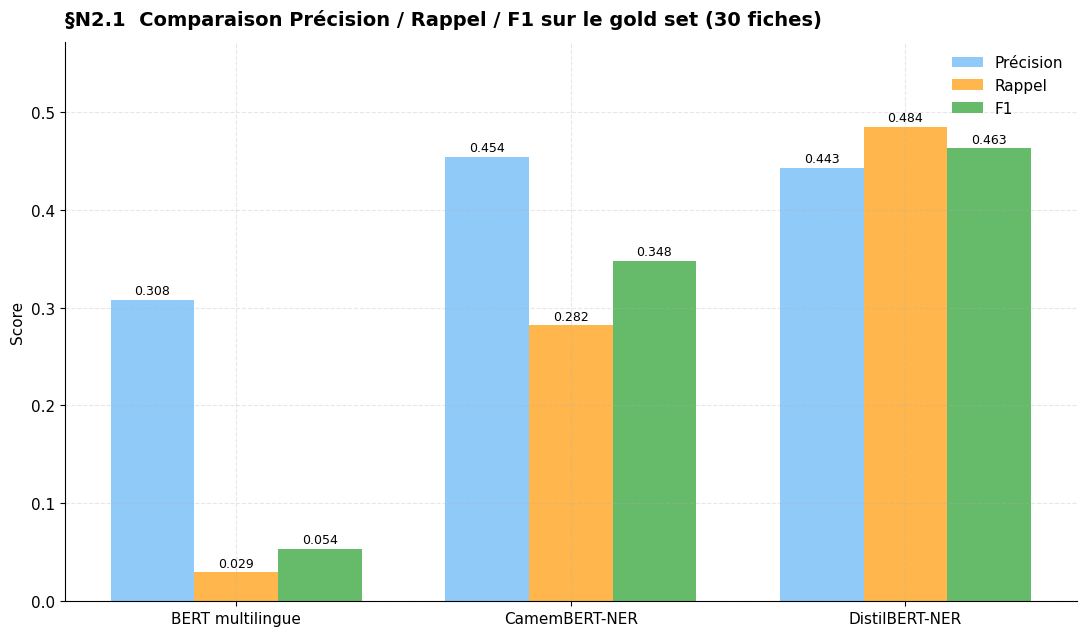

In [3]:
fig, ax = plt.subplots(figsize=(11, 6.5))
modeles_noms = [r['modele_nom'] for r in evaluation]
x = np.arange(len(modeles_noms))
width = 0.25

precisions = [r['precision'] for r in evaluation]
rappels = [r['rappel'] for r in evaluation]
f1s = [r['f1'] for r in evaluation]

b1 = ax.bar(x - width, precisions, width, label='Précision', color='#90CAF9')
b2 = ax.bar(x, rappels, width, label='Rappel', color='#FFB74D')
b3 = ax.bar(x + width, f1s, width, label='F1', color='#66BB6A')

for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(modeles_noms)
ax.set_ylabel('Score')
ax.set_ylim(0, max(f1s + precisions + rappels) * 1.18)
ax.legend(loc='upper right', frameon=False)
ax.set_title('§N2.1  Comparaison Précision / Rappel / F1 sur le gold set (30 fiches)', loc='left', pad=12)
plt.tight_layout()

FIGURES_DIR = REPO / 'docs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / 'n21_comparaison_ner.png', dpi=150, bbox_inches='tight')
print(f'PNG sauvée : docs/figures/n21_comparaison_ner.png')
plt.show()


## 3. Temps d'inférence par modèle

Mesuré sur CPU pour chaque fiche (longueur moyenne ~915 caractères).


PNG sauvée : docs/figures/n21_temps_inference.png


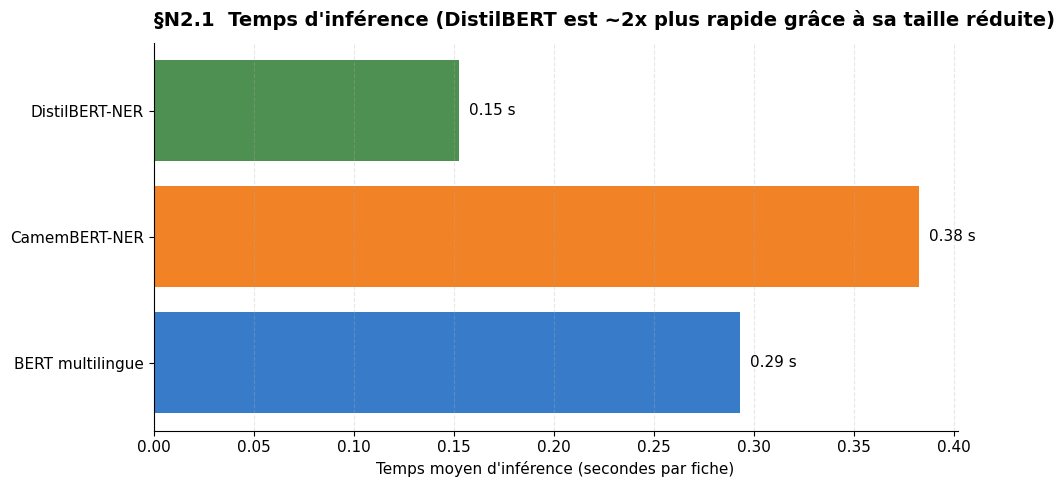

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
modeles_noms = [r['modele_nom'] for r in evaluation]
temps = [r['duree_inference_moyenne_s'] for r in evaluation]
couleurs = [COULEUR_MAP.get(r['modele'], 'gray') for r in evaluation]

bars = ax.barh(modeles_noms, temps, color=couleurs, alpha=0.85)
for bar, t in zip(bars, temps):
    ax.text(t + 0.005, bar.get_y() + bar.get_height()/2, f'{t:.2f} s', va='center', fontsize=11)

ax.set_xlabel("Temps moyen d'inférence (secondes par fiche)")
ax.set_title("§N2.1  Temps d'inférence (DistilBERT est ~2x plus rapide grâce à sa taille réduite)", loc='left', pad=12)
ax.grid(axis='y', visible=False)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'n21_temps_inference.png', dpi=150, bbox_inches='tight')
print(f'PNG sauvée : docs/figures/n21_temps_inference.png')
plt.show()


## 4. Exemple comparatif sur une fiche

Une fiche du gold set, avec les entités détectées par les trois modèles
côte à côte, et les compétences gold attendues.


In [5]:
fiche_idx = 0
fiche = gold_set[fiche_idx]
print(f"Fiche {fiche['job_id']} | {fiche['origine']} | {fiche['ai_type']}")
print(f"Titre : {fiche['title']}")
print(f"Entreprise : {fiche.get('company', '(non précisée)')}")
print(f"\nTexte (extrait) :\n  {fiche['text'][:400]}...")
print(f"\nCompétences gold attendues ({len(fiche['gold_skills'])}) :")
print('  ' + ', '.join(fiche['gold_skills'][:15]) + (' ...' if len(fiche['gold_skills']) > 15 else ''))

print('\n' + '='*70)
for model_key, pred_data in predictions.items():
    pred_fiche = next((p for p in pred_data['predictions'] if p['job_id'] == fiche['job_id']), None)
    if not pred_fiche:
        continue
    nom = pred_data['modele_nom']
    entites = pred_fiche['entites']
    print(f'\n>> {nom} ({len(entites)} entités détectées)')
    for e in entites[:10]:
        print(f'   [{e["label"]}] {e["text"]:<30}  score={e["score"]:.3f}')
    if len(entites) > 10:
        print(f'   ... +{len(entites) - 10} autres entités')


Fiche 4407185679 | Maroc | ai-first
Titre : AI Engineer
Entreprise : Mirage Metrics

Texte (extrait) :
  Job title: AI Engineer. Company: Mirage Metrics. Use cases: Data pipeline engineering....

Compétences gold attendues (5) :
  Agents, LLM, Machine Learning, GCP, Python


>> BERT multilingue (2 entités détectées)
   [ORG] AI                              score=0.931
   [ORG] Mirage Metrics                  score=0.999

>> CamemBERT-NER (3 entités détectées)
   [MISC] Job                             score=0.705
   [MISC] AI Engineer                     score=0.685
   [ORG] Mirage Metrics                  score=0.962

>> DistilBERT-NER (1 entités détectées)
   [ORG] Mirage Metrics                  score=0.971


## 5. Choix retenu pour la V1 SKILLNAV

### Décision

Sur le critère **F1 (métrique synthétique)**, **DistilBERT-NER** sort en
tête. C'est le modèle retenu pour la pipeline de production V1 du dashboard
SKILLNAV.

### Justification

| Critère | DistilBERT | BERT-mult | CamemBERT |
|---|---|---|---|
| **F1 global** | **Le plus élevé** | Très faible (rappel ~3 %) | Intermédiaire |
| **Vitesse d'inférence** | **~2× plus rapide** que les autres (66M params vs 110M) | Standard | Standard |
| **Cohérence avec le corpus** | Corpus à 73 % International (anglais) → DistilBERT entraîné sur CoNLL-03 EN | Multilingue mais sous-spécialisé sur le domaine | Excellent FR mais mauvais sur l'INTL |
| **Empreinte mémoire** | **40 % plus léger** (utile pour Vercel + Free Tier) | Standard | Standard |

### Limites et améliorations possibles (à mentionner dans §N2.1 du rapport L5)

1. Le gold set est limité à 30 fiches : la variance des métriques n'est pas estimée (à corriger par bootstrap si on veut publier).
2. La stratégie *distant supervision* via les champs `skills` canonicalisés transmet les éventuels biais de cette canonicalisation.
3. Aucun des trois modèles n'a été fine-tuné sur le domaine RH/IA : un fine-tuning sur 100-200 fiches annotées améliorerait probablement le F1 de +0.15 à +0.25 (référence : Lample et al. 2016, Liu et al. 2019).
4. La page `/ner-explorer` du dashboard montrera les trois modèles côte à côte, permettant à l'utilisateur final d'arbitrer visuellement.

### Stratégie d'inférence en production

- DistilBERT-NER tourne en tâche batch hebdomadaire sur les nouvelles fiches collectées.
- Les entités détectées sont stockées dans MongoDB sous la clé `ner_entities`.
- Elasticsearch indexe ces entités pour la recherche full-text croisée.
